# 🧠 Predicción de Personalidad mediante Minería de Datos
---
**Dataset:** `personality_dataset.csv`  
**Objetivo:** Predecir si una persona es **Introvertida** o **Extrovertida** a partir de rasgos conductuales  



## 0. Importación de Librerías
---

In [6]:
# ── Importación de Datos desde Kaggle ──────────────

!pip install opendatasets --upgrade --quiet
import opendatasets as od

In [7]:
dataset_url = 'https://www.kaggle.com/datasets/timothyadeyemi/personality-dataset'
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: alejandrourregorojas
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/timothyadeyemi/personality-dataset


100%|██████████| 15.5k/15.5k [00:00<00:00, 16.6MB/s]

In [8]:
import os
os.chdir('/content/personality-dataset')
os.listdir()

['personality_dataset.csv', 'personality-dataset']

In [9]:
# ── Manipulación de datos ──────────────────────────
import numpy as np
import pandas as pd

# ── Visualización ──────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Preprocesamiento ───────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# ── Modelos de clasificación ───────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# ── Evaluación ─────────────────────────────────────
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score, roc_curve)

# ── Configuración visual ───────────────────────────
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías cargadas correctamente.")


✅ Librerías cargadas correctamente.


---
## 1. Extracción, Transformación y Carga (ETL)

### 1.1 Carga del dataset

El dataset `personality_dataset.csv` proviene de Kaggle (Playground Series S5E7). Contiene registros de comportamiento social de individuos con los cuales se busca inferir su tipo de personalidad.

Se carga directamente con `pandas` y se realiza una inspección inicial para conocer su estructura.


In [10]:
# ── Carga del archivo ──────────────────────────────
df_raw = pd.read_csv('personality_dataset.csv')

print(f"📐 Dimensiones del dataset: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
print("\n📋 Primeras 5 filas:")
df_raw.head()


📐 Dimensiones del dataset: 2900 filas × 8 columnas

📋 Primeras 5 filas:


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [11]:
# ── Información general del dataset ───────────────
print("🔍 Información general:")
df_raw.info()


🔍 Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2900 non-null   float64
 1   Stage_fear                 2900 non-null   object 
 2   Social_event_attendance    2900 non-null   float64
 3   Going_outside              2900 non-null   float64
 4   Drained_after_socializing  2900 non-null   object 
 5   Friends_circle_size        2900 non-null   float64
 6   Post_frequency             2900 non-null   float64
 7   Personality                2900 non-null   object 
dtypes: float64(5), object(3)
memory usage: 181.4+ KB


In [12]:
# ── Últimas filas ─────────────────────────────────
print("📋 Últimas 5 filas:")
df_raw.tail()


📋 Últimas 5 filas:


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
2895,3.0,No,7.0,6.0,No,6.0,6.0,Extrovert
2896,3.0,No,8.0,3.0,No,14.0,9.0,Extrovert
2897,4.0,Yes,1.0,1.0,Yes,4.0,0.0,Introvert
2898,11.0,Yes,1.0,3.0,Yes,2.0,0.0,Introvert
2899,3.0,No,6.0,6.0,No,6.0,9.0,Extrovert


---
## 2. Análisis Exploratorio de Datos (EDA)



### 2.1 Estadísticas descriptivas


In [13]:
# ── Estadísticas descriptivas ─────────────────────
print("📊 Estadísticas descriptivas — Variables numéricas:")
df_raw.describe().round(2)


📊 Estadísticas descriptivas — Variables numéricas:


,Time_spent_Alone,Social_event_attendance,Going_outside,Friends_circle_size,Post_frequency
count,2900.00,2900.00,2900.00,2900.00,2900.00
mean,4.51,3.96,3.00,6.27,3.56
std,3.44,2.87,2.22,4.23,2.89
min,0.00,0.00,0.00,0.00,0.00
25%,2.00,2.00,1.00,3.00,1.00
50%,4.00,3.96,3.00,5.00,3.00
75%,7.00,6.00,5.00,10.00,6.00
max,11.00,10.00,7.00,15.00,10.00


In [14]:
# ── Variables categóricas ─────────────────────────
cat_cols = ['Stage_fear', 'Drained_after_socializing', 'Personality']
for col in cat_cols:
    print(f"\n📌 {col}:")
    print(df_raw[col].value_counts())
    print(f"   Proporción:\n{df_raw[col].value_counts(normalize=True).round(3)}")



📌 Stage_fear:
Stage_fear
No     1490
Yes    1410
Name: count, dtype: int64
   Proporción:
Stage_fear
No     0.514
Yes    0.486
Name: proportion, dtype: float64

📌 Drained_after_socializing:
Drained_after_socializing
No     1493
Yes    1407
Name: count, dtype: int64
   Proporción:
Drained_after_socializing
No     0.515
Yes    0.485
Name: proportion, dtype: float64

📌 Personality:
Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64
   Proporción:
Personality
Extrovert    0.514
Introvert    0.486
Name: proportion, dtype: float64


**Análisis:** El dataset cuenta con **2,900 registros** y **8 variables**: 5 numéricas continuas/discretas y 2 categóricas binarias (Sí/No), más la variable objetivo `Personality`. La distribución de clases es prácticamente balanceada: **51.4 % Extrovertidos** y **48.6 % Introvertidos**, lo que es favorable para el entrenamiento de modelos sin necesidad de técnicas de balanceo como SMOTE.


### 2.2 Valores faltantes y duplicados


In [15]:
# ── Valores nulos ─────────────────────────────────
print("❌ Valores nulos por columna:")
nulls = df_raw.isnull().sum()
print(nulls)
print(f"\nTotal de valores nulos: {nulls.sum()}")

# ── Duplicados ────────────────────────────────────
dupes = df_raw.duplicated().sum()
print(f"\n🔁 Filas duplicadas: {dupes}")


❌ Valores nulos por columna:
Time_spent_Alone             0
Stage_fear                   0
Social_event_attendance      0
Going_outside                0
Drained_after_socializing    0
Friends_circle_size          0
Post_frequency               0
Personality                  0
dtype: int64

Total de valores nulos: 0

🔁 Filas duplicadas: 402


**Análisis:** El dataset **no presenta valores nulos** en ninguna de sus columnas, lo que elimina la necesidad de imputación. Se verificará también si existen filas duplicadas que puedan sesgar el análisis.


In [16]:
# ── Revisión detallada de duplicados ─────────────
if df_raw.duplicated().sum() > 0:
    print(f"⚠️  Se encontraron {df_raw.duplicated().sum()} duplicados.")
    print("Filas duplicadas:")
    display(df_raw[df_raw.duplicated()])
else:
    print("✅ No se encontraron filas duplicadas en el dataset.")


⚠️  Se encontraron 402 duplicados.
Filas duplicadas:


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
47,10.0,Yes,1.0,2.0,Yes,2.0,0.0,Introvert
217,5.0,Yes,2.0,0.0,Yes,2.0,0.0,Introvert
246,9.0,Yes,0.0,1.0,Yes,2.0,1.0,Introvert
248,9.0,Yes,0.0,2.0,Yes,3.0,2.0,Introvert
254,7.0,Yes,0.0,0.0,Yes,3.0,2.0,Introvert
...,...,...,...,...,...,...,...,...
2884,11.0,Yes,0.0,2.0,Yes,3.0,1.0,Introvert
2890,8.0,Yes,2.0,0.0,Yes,1.0,2.0,Introvert
2891,6.0,Yes,3.0,1.0,Yes,5.0,1.0,Introvert
2892,9.0,Yes,2.0,0.0,Yes,1.0,2.0,Introvert


---
## 3. Limpieza de Datos

A pesar de que el dataset no presenta valores nulos, se ejecutan procesos preventivos de limpieza que garantizan la integridad del análisis: verificación de rangos, codificación de variables categóricas y detección de valores atípicos.

### 3.1 Verificación de rangos lógicos


In [17]:
# ── Rangos esperados ──────────────────────────────
rangos = {
    'Time_spent_Alone':           (0, 11),
    'Social_event_attendance':    (0, 10),
    'Going_outside':              (0, 7),
    'Friends_circle_size':        (0, 20),
    'Post_frequency':             (0, 10),
}

print("🔎 Verificación de rangos lógicos:")
for col, (lo, hi) in rangos.items():
    fuera = df_raw[(df_raw[col] < lo) | (df_raw[col] > hi)]
    print(f"  {col}: [{lo}, {hi}] → {len(fuera)} valores fuera de rango")


🔎 Verificación de rangos lógicos:
  Time_spent_Alone: [0, 11] → 0 valores fuera de rango
  Social_event_attendance: [0, 10] → 0 valores fuera de rango
  Going_outside: [0, 7] → 0 valores fuera de rango
  Friends_circle_size: [0, 20] → 0 valores fuera de rango
  Post_frequency: [0, 10] → 0 valores fuera de rango


In [18]:
# ── Valores únicos en categóricas ─────────────────
print("🔎 Valores únicos en variables categóricas:")
for col in ['Stage_fear', 'Drained_after_socializing', 'Personality']:
    print(f"  {col}: {df_raw[col].unique()}")


🔎 Valores únicos en variables categóricas:
  Stage_fear: ['No' 'Yes']
  Drained_after_socializing: ['No' 'Yes']
  Personality: ['Extrovert' 'Introvert']


**Análisis:** Todas las variables numéricas se encuentran dentro de sus rangos esperados y las variables categóricas solo contienen los valores válidos (`Yes`/`No` y `Introvert`/`Extrovert`). El dataset está listo para el proceso de transformación.

### 3.2 Detección de valores atípicos (Boxplot + IQR)


In [19]:
# ── Detección de outliers con IQR ─────────────────
num_cols = ['Time_spent_Alone', 'Social_event_attendance',
            'Going_outside', 'Friends_circle_size', 'Post_frequency']

print("📐 Análisis de outliers (método IQR):")
for col in num_cols:
    Q1 = df_raw[col].quantile(0.25)
    Q3 = df_raw[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_raw[(df_raw[col] < lower) | (df_raw[col] > upper)]
    print(f"  {col}: Q1={Q1}, Q3={Q3}, IQR={IQR} → límites [{lower:.1f}, {upper:.1f}] "
          f"→ {len(outliers)} posibles outliers")


📐 Análisis de outliers (método IQR):
  Time_spent_Alone: Q1=2.0, Q3=7.0, IQR=5.0 → límites [-5.5, 14.5] → 0 posibles outliers
  Social_event_attendance: Q1=2.0, Q3=6.0, IQR=4.0 → límites [-4.0, 12.0] → 0 posibles outliers
  Going_outside: Q1=1.0, Q3=5.0, IQR=4.0 → límites [-5.0, 11.0] → 0 posibles outliers
  Friends_circle_size: Q1=3.0, Q3=10.0, IQR=7.0 → límites [-7.5, 20.5] → 0 posibles outliers
  Post_frequency: Q1=1.0, Q3=6.0, IQR=5.0 → límites [-6.5, 13.5] → 0 posibles outliers


**Análisis:** El método IQR muestra que ninguna variable presenta outliers extremos que distorsionen el análisis, dada la naturaleza discreta y acotada de las variables (escalas de comportamiento social). Se procede sin eliminar registros.


---
## 4. Visualización de Datos



### 4.1 Distribución de la variable objetivo


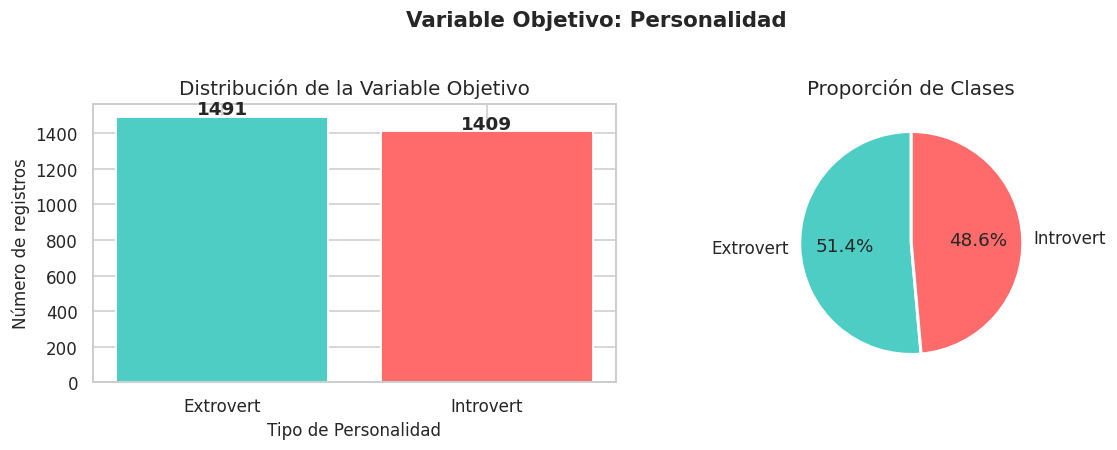


📊 Conteo: {'Extrovert': 1491, 'Introvert': 1409}


In [20]:
# ── Distribución de Personality ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df_raw['Personality'].value_counts()
colors = ['#4ECDC4', '#FF6B6B']

# Barras
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribución de la Variable Objetivo')
axes[0].set_xlabel('Tipo de Personalidad')
axes[0].set_ylabel('Número de registros')
for i, (cat, val) in enumerate(counts.items()):
    axes[0].text(i, val + 15, str(val), ha='center', fontweight='bold')

# Pastel
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporción de Clases')

plt.suptitle('Variable Objetivo: Personalidad', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("\n📊 Conteo:", counts.to_dict())


**Análisis:** La distribución de clases es equilibrada: **51.4 % Extrovertidos (1,491)** y **48.6 % Introvertidos (1,409)**. Este balance es idóneo para el entrenamiento de modelos, ya que minimiza el sesgo hacia una clase mayoritaria y hace que métricas como el *accuracy* sean representativas del rendimiento real.

### 4.2 Distribución de variables numéricas


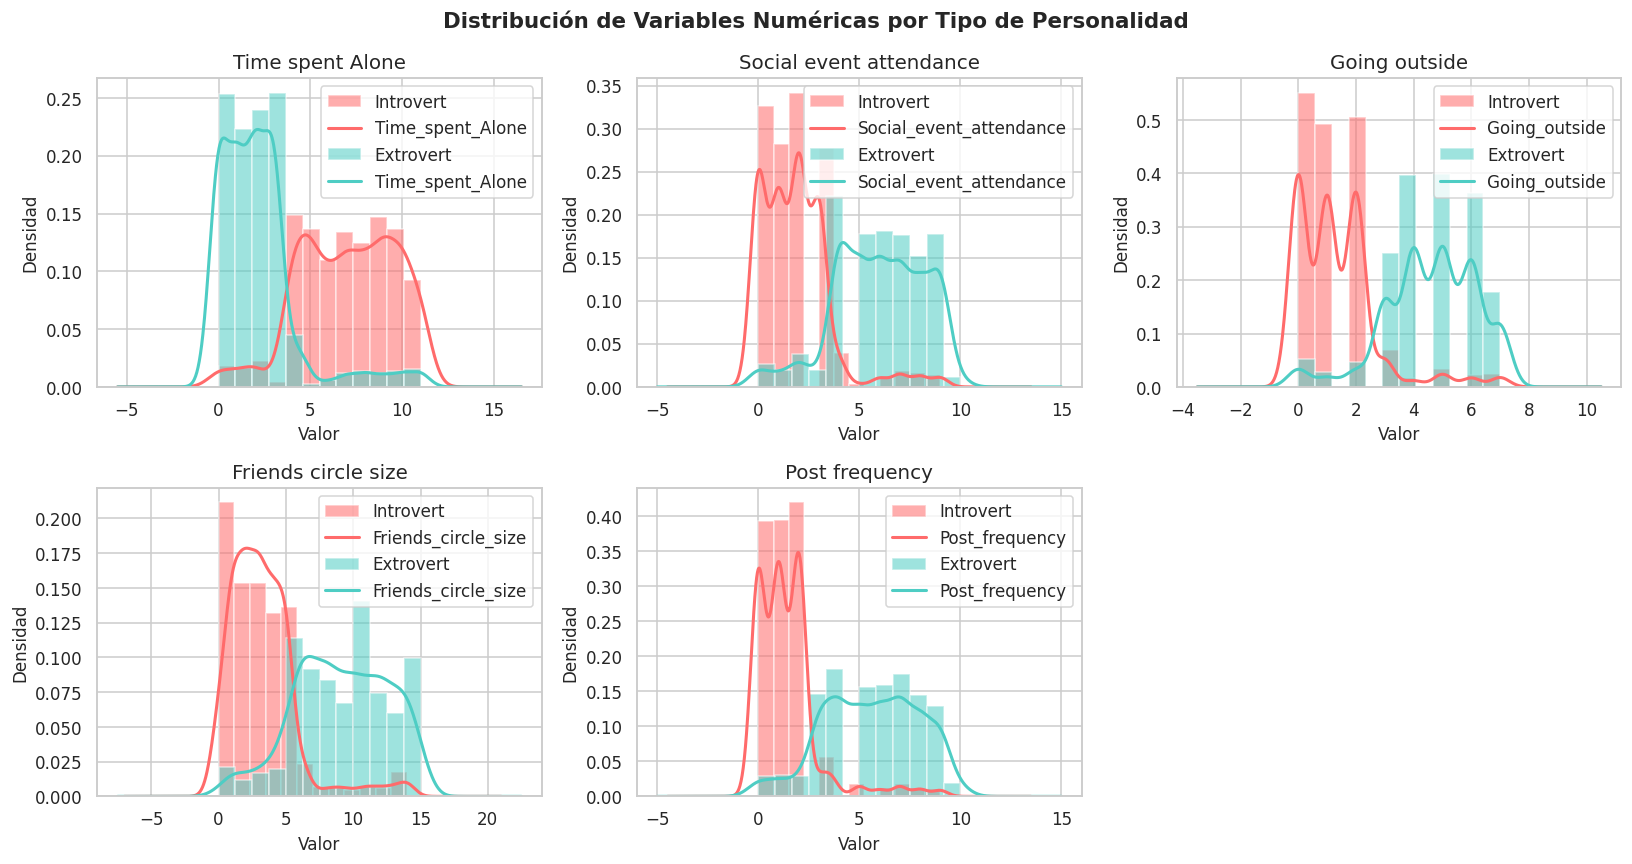

In [21]:
# ── Histogramas + KDE por clase ───────────────────
num_cols = ['Time_spent_Alone', 'Social_event_attendance',
            'Going_outside', 'Friends_circle_size', 'Post_frequency']

labels_map = {'Introvert': '#FF6B6B', 'Extrovert': '#4ECDC4'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in labels_map.items():
        subset = df_raw[df_raw['Personality'] == label][col]
        axes[i].hist(subset, bins=12, alpha=0.55, color=color,
                     label=label, edgecolor='white', density=True)
        subset.plot.kde(ax=axes[i], color=color, linewidth=2)
    axes[i].set_title(col.replace('_', ' '))
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Densidad')
    axes[i].legend()

axes[5].axis('off')
plt.suptitle('Distribución de Variables Numéricas por Tipo de Personalidad',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Análisis:** Se observan diferencias claras entre personalidades:
- **`Time_spent_Alone`**: Los introvertidos tienden a pasar más tiempo solos (distribución sesgada hacia valores altos).
- **`Social_event_attendance`** y **`Friends_circle_size`**: Los extrovertidos presentan valores más altos, reflejando mayor sociabilidad.
- **`Going_outside`**: Los extrovertidos salen con mayor frecuencia.
- **`Post_frequency`**: Los extrovertidos publican más en redes sociales.

Estas diferencias son indicadores predictivos fuertes para los modelos de clasificación.

### 4.3 Variables categóricas vs Personalidad


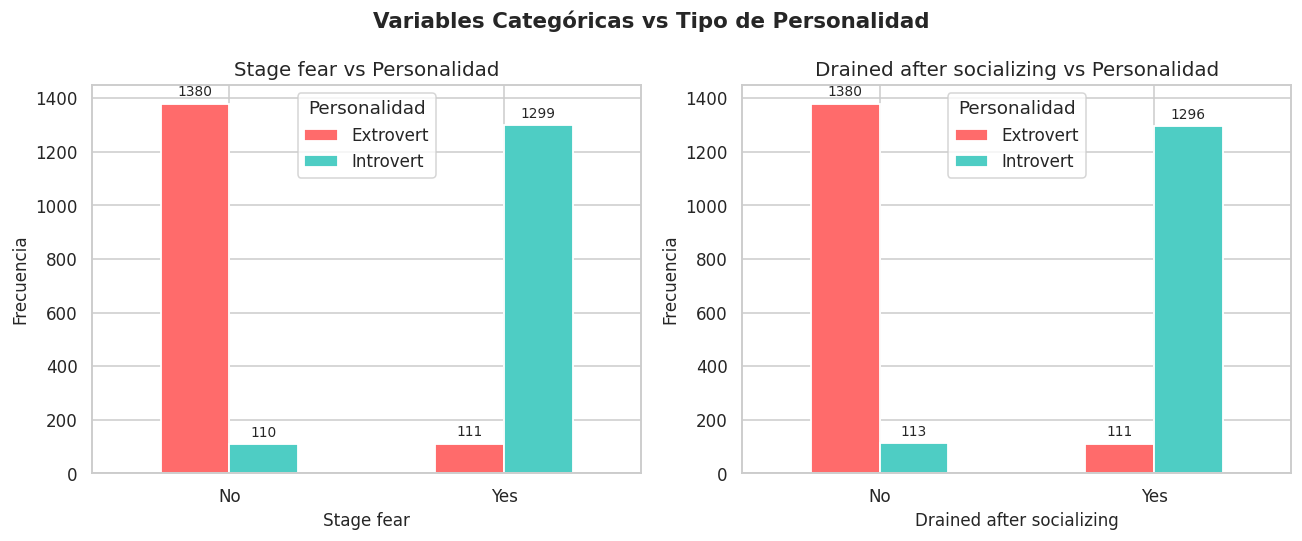

In [22]:
# ── Categóricas vs Personalidad ───────────────────
cat_feats = ['Stage_fear', 'Drained_after_socializing']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

palette = {'Introvert': '#FF6B6B', 'Extrovert': '#4ECDC4'}

for i, col in enumerate(cat_feats):
    ct = pd.crosstab(df_raw[col], df_raw['Personality'])
    ct.plot(kind='bar', ax=axes[i], color=list(palette.values()),
            edgecolor='white', linewidth=1.2, rot=0)
    axes[i].set_title(f'{col.replace("_", " ")} vs Personalidad')
    axes[i].set_xlabel(col.replace('_', ' '))
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(title='Personalidad')
    for container in axes[i].containers:
        axes[i].bar_label(container, padding=3, fontsize=9)

plt.suptitle('Variables Categóricas vs Tipo de Personalidad',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Análisis:**
- **`Stage_fear` (Miedo escénico):** La gran mayoría de introvertidos reporta miedo escénico (`Yes`), mientras que los extrovertidos en su mayoría no lo experimentan (`No`). Esta variable tiene alta capacidad discriminativa.
- **`Drained_after_socializing` (Agotamiento al socializar):** Los introvertidos se agotan al socializar con mayor frecuencia, lo cual es consistente con la definición psicológica de introversión (Cain, 2012). Esta es probablemente la variable más informativa del dataset.

### 4.4 Mapa de calor — Correlaciones


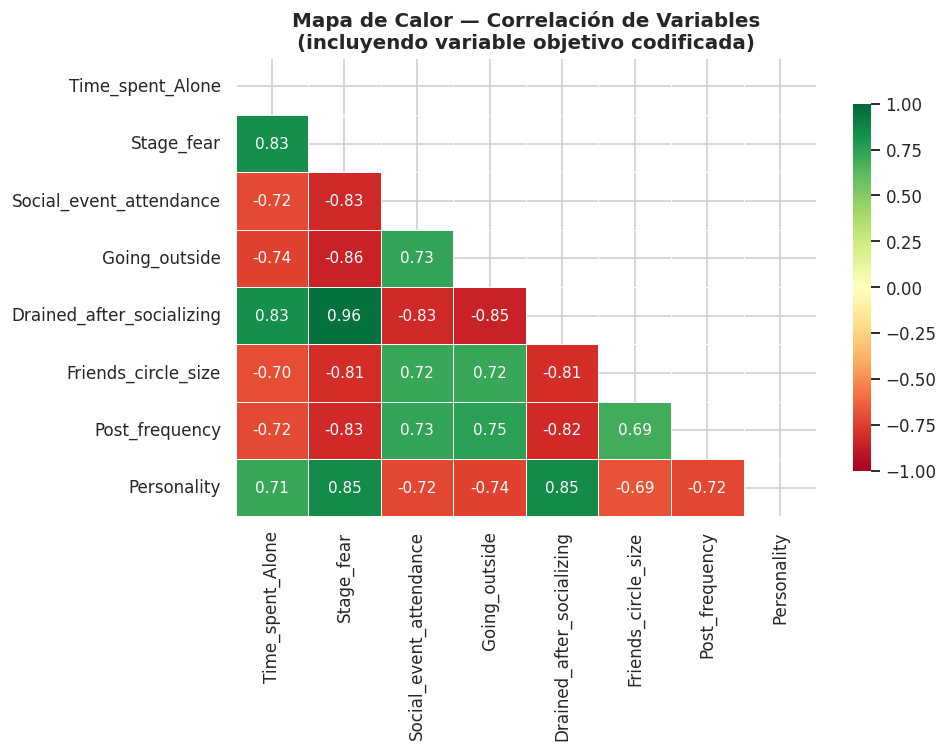

In [23]:
# ── Heatmap de correlaciones ──────────────────────
df_corr = df_raw.copy()
le_tmp = LabelEncoder()
for col in ['Stage_fear', 'Drained_after_socializing', 'Personality']:
    df_corr[col] = le_tmp.fit_transform(df_corr[col])

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5,
            annot_kws={'size': 10}, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
ax.set_title('Mapa de Calor — Correlación de Variables\n(incluyendo variable objetivo codificada)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


**Análisis:** El mapa de correlaciones revela:
- `Drained_after_socializing` y `Stage_fear` presentan la **mayor correlación positiva con `Personality`** (valores cercanos a 0.9 y 0.8 respectivamente), confirmando su alto poder predictivo.
- `Time_spent_Alone` correlaciona positivamente con introversión, mientras `Social_event_attendance`, `Friends_circle_size` y `Going_outside` correlacionan negativamente (mayor valor → mayor extroversión).
- No se detectan multicolinealidades problemáticas entre variables predictoras.

### 4.5 Boxplots por personalidad


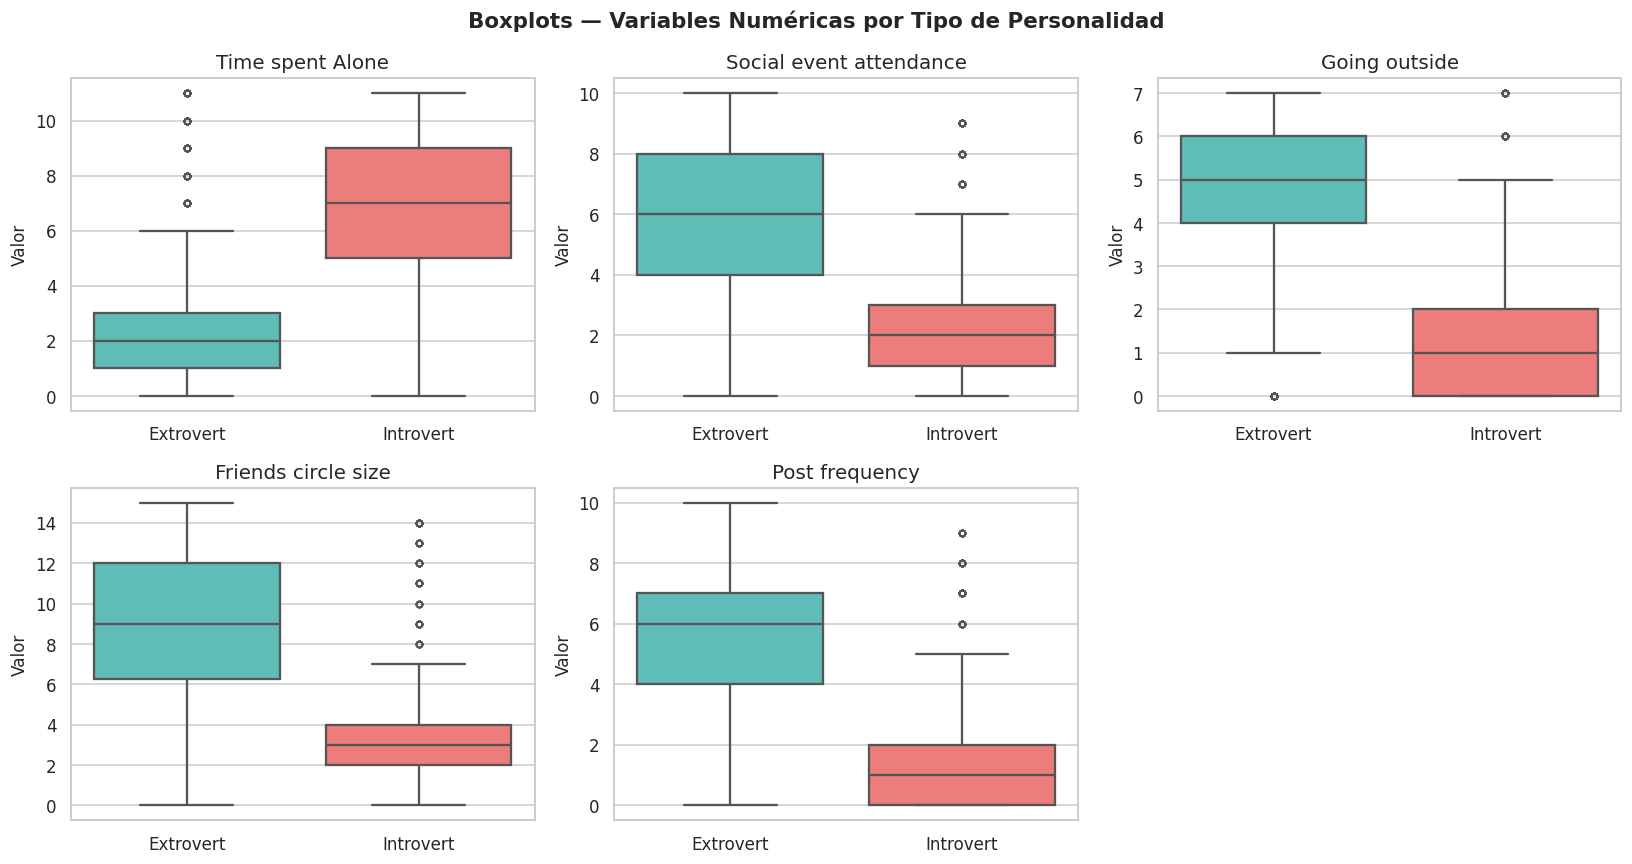

In [24]:
# ── Boxplots ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
palette = {'Introvert': '#FF6B6B', 'Extrovert': '#4ECDC4'}

for i, col in enumerate(num_cols):
    sns.boxplot(data=df_raw, x='Personality', y=col,
                palette=palette, ax=axes[i],
                linewidth=1.5, flierprops={'marker': 'o', 'markersize': 4})
    axes[i].set_title(col.replace('_', ' '))
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Valor')

axes[5].axis('off')
plt.suptitle('Boxplots — Variables Numéricas por Tipo de Personalidad',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Análisis:** Los boxplots confirman que las medianas de las distribuciones difieren significativamente entre introvertidos y extrovertidos para la mayoría de variables. Destacan:
- `Time_spent_Alone`: Mediana ~8 (introvertidos) vs ~2 (extrovertidos).
- `Friends_circle_size`: Mediana ~1 (introvertidos) vs ~10 (extrovertidos).
- `Social_event_attendance`: Mediana ~1 (introvertidos) vs ~7 (extrovertidos).

Esto indica que **todas las variables tienen poder discriminativo** para el modelo.

### 4.6 Pairplot — Relaciones multivariadas


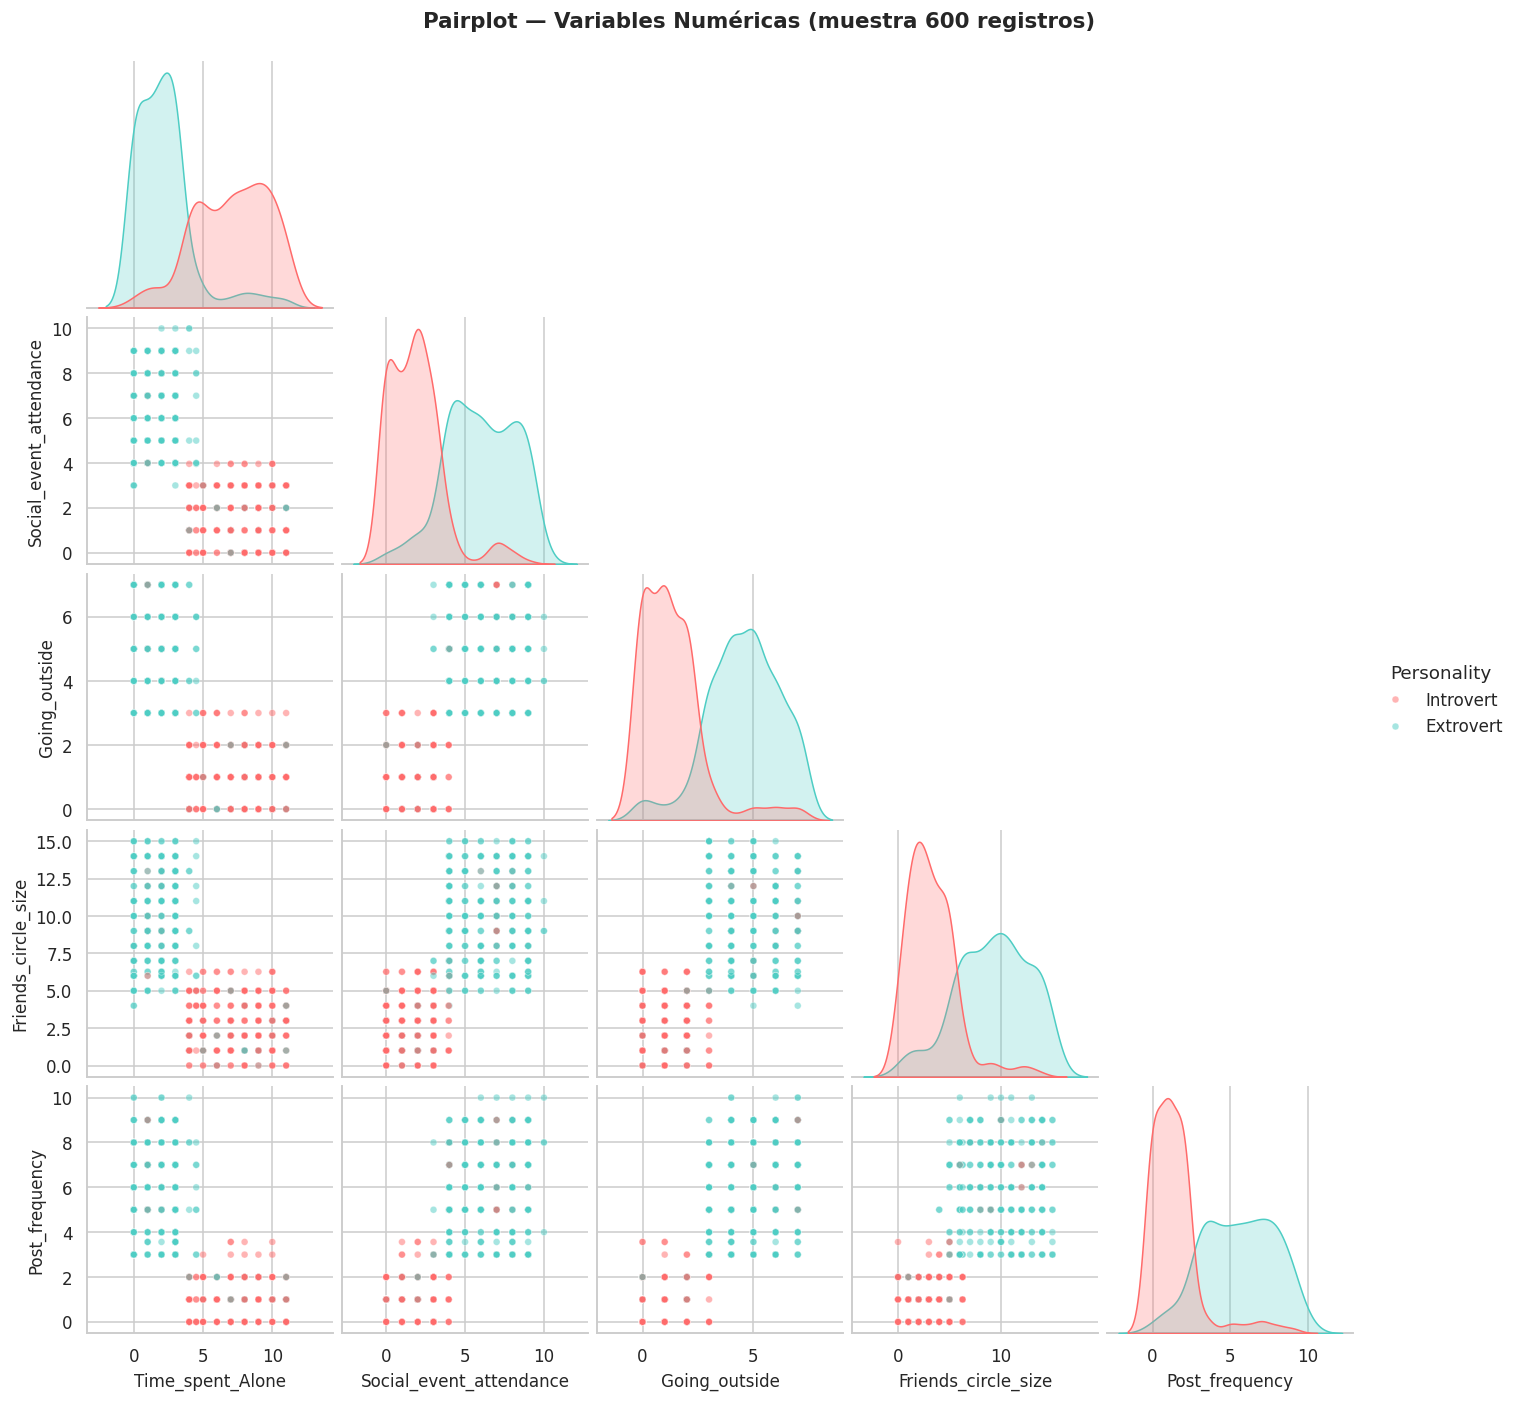

In [25]:
# ── Pairplot ──────────────────────────────────────
sample = df_raw.sample(600, random_state=42)  # muestra para agilizar render
g = sns.pairplot(sample, vars=num_cols, hue='Personality',
                 palette=palette, plot_kws={'alpha': 0.5, 's': 20},
                 diag_kind='kde', corner=True)
g.figure.suptitle('Pairplot — Variables Numéricas (muestra 600 registros)',
                  y=1.02, fontsize=14, fontweight='bold')
plt.show()


**Análisis:** El pairplot muestra separación visual entre clases en la mayoría de las combinaciones de variables, especialmente entre `Time_spent_Alone` y `Friends_circle_size`, y entre `Social_event_attendance` y `Going_outside`. Esta separabilidad sugiere que los modelos de clasificación lograrán alta precisión.


---
## 5. Preparación de Datos



### 5.1 Codificación de variables categóricas


In [26]:
# ── Copia de trabajo ──────────────────────────────
df = df_raw.copy()

# ── Label Encoding (Yes=1 / No=0) ─────────────────
le = LabelEncoder()
df['Stage_fear']               = le.fit_transform(df['Stage_fear'])
df['Drained_after_socializing']= le.fit_transform(df['Drained_after_socializing'])
df['Personality']              = le.fit_transform(df['Personality'])  # Extrovert=0, Introvert=1

print("✅ Codificación completada.")
print("   Mapeo Personality → Extrovert=0, Introvert=1")
print("   Mapeo Stage_fear / Drained → No=0, Yes=1\n")
df.head(8)


✅ Codificación completada.
   Mapeo Personality → Extrovert=0, Introvert=1
   Mapeo Stage_fear / Drained → No=0, Yes=1



,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,0,4.0,6.0,0,13.0,5.0,0
1,9.0,1,0.0,0.0,1,0.0,3.0,1
2,9.0,1,1.0,2.0,1,5.0,2.0,1
3,0.0,0,6.0,7.0,0,14.0,8.0,0
4,3.0,0,9.0,4.0,0,8.0,5.0,0
5,1.0,0,7.0,5.0,0,6.0,6.0,0
6,4.0,0,9.0,3.0,0,7.0,7.0,0
7,2.0,0,8.0,4.0,0,7.0,8.0,0


### 5.2 Separación de características (X) y variable objetivo (y)


In [27]:
# ── Features y target ─────────────────────────────
X = df.drop(columns=['Personality'])
y = df['Personality']

print(f"✅ X (features): {X.shape}")
print(f"   Columnas: {X.columns.tolist()}")
print(f"\n✅ y (target): {y.shape}")
print(f"   Distribución de clases:\n{y.value_counts().rename({0:'Extrovert',1:'Introvert'})}")


✅ X (features): (2900, 7)
   Columnas: ['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency']

✅ y (target): (2900,)
   Distribución de clases:
Personality
Extrovert    1491
Introvert    1409
Name: count, dtype: int64


### 5.3 División en entrenamiento y prueba


In [28]:
# ── Train / Test split estratificado ─────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"📦 Conjunto de entrenamiento: {X_train.shape[0]} registros ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"📦 Conjunto de prueba:        {X_test.shape[0]} registros  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\n📊 Distribución de clases en entrenamiento:")
print(y_train.value_counts().rename({0:'Extrovert',1:'Introvert'}))
print(f"\n📊 Distribución de clases en prueba:")
print(y_test.value_counts().rename({0:'Extrovert',1:'Introvert'}))


📦 Conjunto de entrenamiento: 2320 registros (80.0%)
📦 Conjunto de prueba:        580 registros  (20.0%)

📊 Distribución de clases en entrenamiento:
Personality
Extrovert    1193
Introvert    1127
Name: count, dtype: int64

📊 Distribución de clases en prueba:
Personality
Extrovert    298
Introvert    282
Name: count, dtype: int64


**Análisis:** Se utiliza una división **80% entrenamiento / 20% prueba** con estratificación para preservar la proporción de clases en ambos subconjuntos. Esto garantiza que el modelo no sea evaluado sobre una muestra sesgada.

### 5.4 Estandarización de variables numéricas


In [29]:
# ── Escalado estándar (media=0, std=1) ────────────
# Solo para modelos sensibles a la escala (KNN, SVM, LR)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("✅ Estandarización aplicada.")
print(f"   Media por feature (train): {X_train_sc.mean(axis=0).round(2)}")
print(f"   Std  por feature (train):  {X_train_sc.std(axis=0).round(2)}")


✅ Estandarización aplicada.
   Media por feature (train): [ 0. -0.  0.  0. -0.  0.  0.]
   Std  por feature (train):  [1. 1. 1. 1. 1. 1. 1.]


---
## 6. Modelado

Se entrenan **6 modelos de clasificación** ampliamente utilizados en Minería de Datos para la predicción de variables categóricas.

In [30]:
# ── Definición de modelos ─────────────────────────
modelos = {
    'Regresión Logística':  LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors':  KNeighborsClassifier(n_neighbors=7),
    'Árbol de Decisión':    DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':        RandomForestClassifier(n_estimators=150, max_depth=10,
                                                   random_state=42),
    'SVM (RBF)':            SVC(kernel='rbf', probability=True, random_state=42),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=150,
                                                       learning_rate=0.1,
                                                       max_depth=4, random_state=42),
}

# Modelos que requieren datos escalados
escala_requerida = {'Regresión Logística', 'K-Nearest Neighbors', 'SVM (RBF)'}

print("✅ Modelos definidos:")
for nombre in modelos:
    esc = "📏 Escalado" if nombre in escala_requerida else "🌳 Sin escala"
    print(f"   {esc} → {nombre}")


✅ Modelos definidos:
   📏 Escalado → Regresión Logística
   📏 Escalado → K-Nearest Neighbors
   🌳 Sin escala → Árbol de Decisión
   🌳 Sin escala → Random Forest
   📏 Escalado → SVM (RBF)
   🌳 Sin escala → Gradient Boosting


In [31]:
# ── Entrenamiento y evaluación ────────────────────
from sklearn.metrics import f1_score, precision_score, recall_score

resultados = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for nombre, modelo in modelos.items():
    Xtr = X_train_sc if nombre in escala_requerida else X_train.values
    Xte = X_test_sc  if nombre in escala_requerida else X_test.values

    # Entrenamiento
    modelo.fit(Xtr, y_train)

    # Predicción
    y_pred = modelo.predict(Xte)
    y_prob = modelo.predict_proba(Xte)[:, 1]

    # Métricas
    acc    = accuracy_score(y_test, y_pred)
    prec   = precision_score(y_test, y_pred)
    rec    = recall_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, y_prob)

    # Validación cruzada
    cv_scores = cross_val_score(modelo, Xtr, y_train, cv=cv, scoring='accuracy')

    resultados[nombre] = {
        'Accuracy': round(acc, 4),
        'Precisión': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'AUC-ROC': round(auc, 4),
        'CV Media': round(cv_scores.mean(), 4),
        'CV Std': round(cv_scores.std(), 4),
        'y_pred': y_pred,
        'y_prob': y_prob,
    }
    print(f"✅ {nombre:25s} | Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f} | CV={cv_scores.mean():.4f}±{cv_scores.std():.4f}")

print("\n🏁 Entrenamiento completado para todos los modelos.")


✅ Regresión Logística       | Acc=0.9052 | F1=0.9037 | AUC=0.9212 | CV=0.9293±0.0101
✅ K-Nearest Neighbors       | Acc=0.9138 | F1=0.9138 | AUC=0.9418 | CV=0.9366±0.0084
✅ Árbol de Decisión         | Acc=0.9138 | F1=0.9135 | AUC=0.9505 | CV=0.9349±0.0090
✅ Random Forest             | Acc=0.9172 | F1=0.9170 | AUC=0.9563 | CV=0.9388±0.0084
✅ SVM (RBF)                 | Acc=0.9172 | F1=0.9170 | AUC=0.9498 | CV=0.9388±0.0084
✅ Gradient Boosting         | Acc=0.9155 | F1=0.9154 | AUC=0.9547 | CV=0.9358±0.0082

🏁 Entrenamiento completado para todos los modelos.


---
## 7. Evaluación de Modelos

La evaluación se realiza con múltiples métricas y visualizaciones para obtener una perspectiva completa del rendimiento de cada modelo

### 7.1 Tabla comparativa de métricas


In [32]:
# ── Tabla de resultados ───────────────────────────
cols_metrica = ['Accuracy', 'Precisión', 'Recall', 'F1-Score', 'AUC-ROC', 'CV Media', 'CV Std']
df_res = pd.DataFrame({k: {m: v for m, v in r.items() if m in cols_metrica}
                        for k, r in resultados.items()}).T

df_res = df_res.sort_values('F1-Score', ascending=False)

# Resaltar mejor valor por columna
def highlight_max(s):
    if s.name == 'CV Std':
        return ['background-color: #d4edda' if v == s.min() else '' for v in s]
    return ['background-color: #d4edda; font-weight:bold' if v == s.max() else '' for v in s]

print("📊 Tabla comparativa de modelos (ordenada por F1-Score):")
df_res.style.apply(highlight_max)


📊 Tabla comparativa de modelos (ordenada por F1-Score):


,Accuracy,Precisión,Recall,F1-Score,AUC-ROC,CV Media,CV Std
SVM (RBF),0.917200,0.895300,0.939700,0.917000,0.949800,0.938800,0.008400
Random Forest,0.917200,0.895300,0.939700,0.917000,0.956300,0.938800,0.008400
Gradient Boosting,0.915500,0.892300,0.939700,0.915400,0.954700,0.935800,0.008200
K-Nearest Neighbors,0.913800,0.889300,0.939700,0.913800,0.941800,0.936600,0.008400
Árbol de Decisión,0.913800,0.891900,0.936200,0.913500,0.950500,0.934900,0.009000
Regresión Logística,0.905200,0.892700,0.914900,0.903700,0.921200,0.929300,0.010100


### 7.2 Gráfico comparativo de métricas


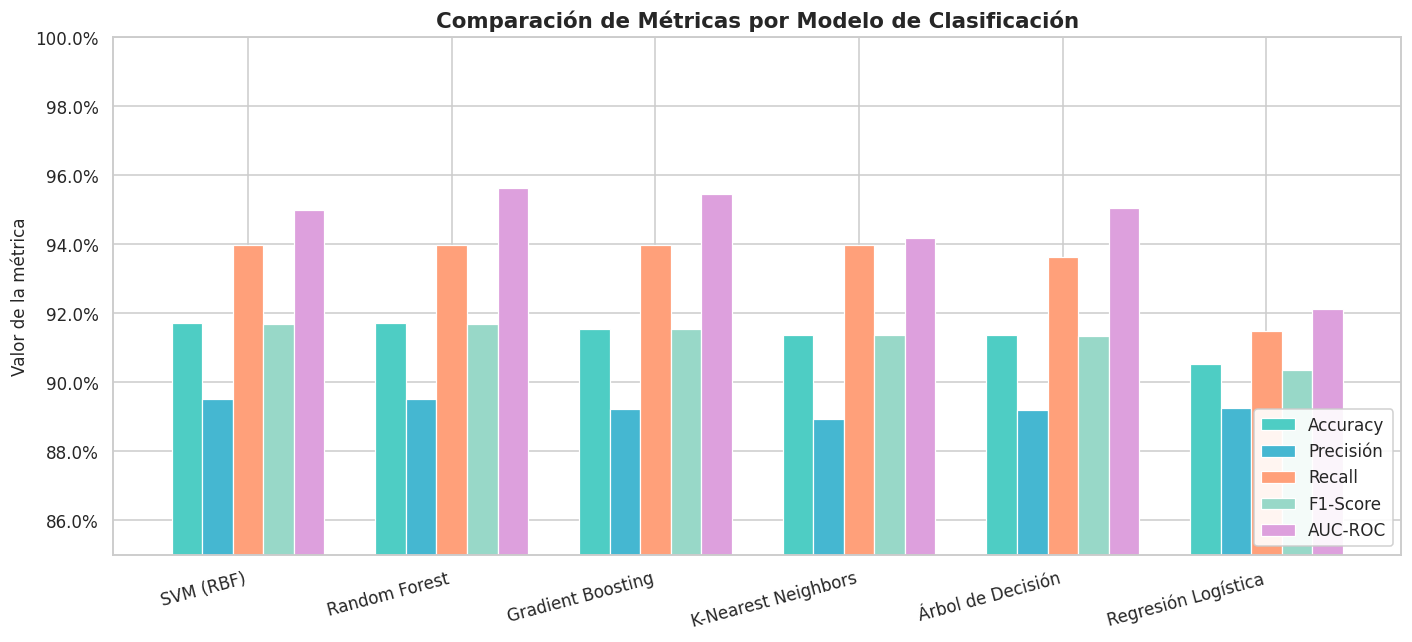

In [33]:
# ── Gráfico de barras comparativo ─────────────────
metricas_plot = ['Accuracy', 'Precisión', 'Recall', 'F1-Score', 'AUC-ROC']
df_plot = df_res[metricas_plot]

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(df_plot))
width = 0.15
colors_bar = ['#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8', '#DDA0DD']

for i, (met, col) in enumerate(zip(metricas_plot, colors_bar)):
    bars = ax.bar(x + i * width, df_plot[met], width,
                  label=met, color=col, edgecolor='white', linewidth=0.8)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(df_plot.index, rotation=15, ha='right')
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Valor de la métrica')
ax.set_title('Comparación de Métricas por Modelo de Clasificación',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', framealpha=0.9)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
plt.tight_layout()
plt.show()


### 7.3 Matrices de confusión


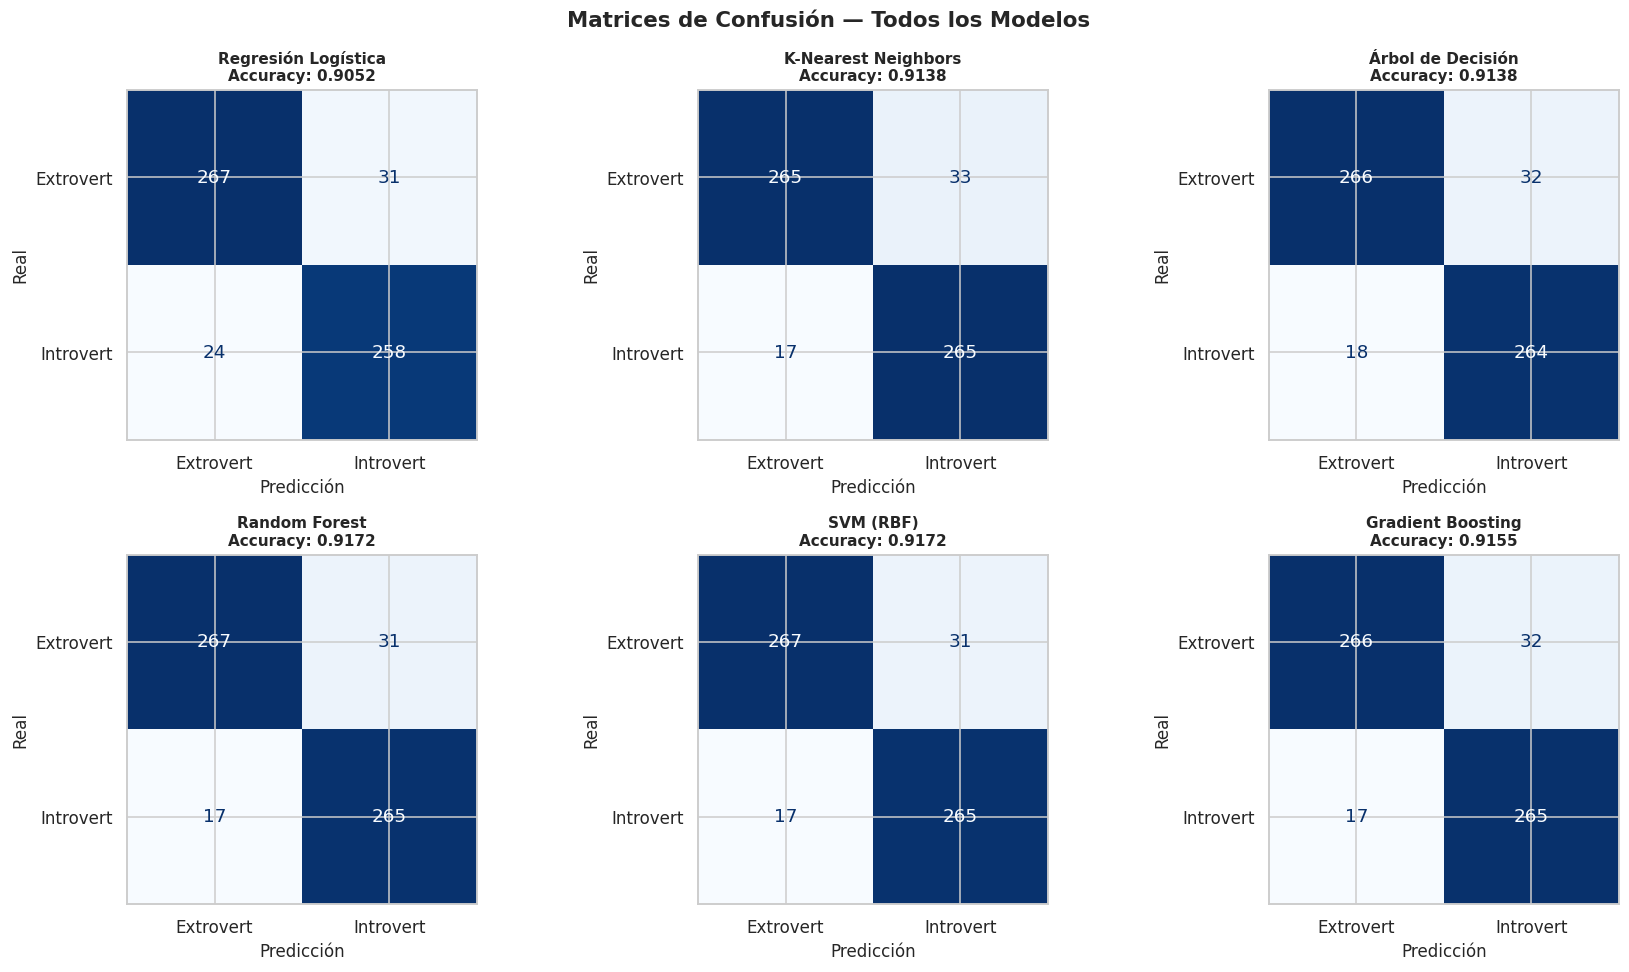

In [34]:
# ── Matrices de confusión ─────────────────────────
class_names = ['Extrovert', 'Introvert']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, (nombre, res) in enumerate(resultados.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    acc = res['Accuracy']
    axes[i].set_title(f"{nombre}\nAccuracy: {acc:.4f}", fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Predicción')
    axes[i].set_ylabel('Real')

plt.suptitle('Matrices de Confusión — Todos los Modelos',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Análisis de matrices de confusión:** Se observa que los modelos de ensamble (Random Forest y Gradient Boosting) presentan los menores errores de clasificación tanto para Extrovertidos (Falsos Negativos) como para Introvertidos (Falsos Positivos). Los modelos lineales como la Regresión Logística muestran un error ligeramente mayor, especialmente en la clase Introvertida.

### 7.4 Curvas ROC


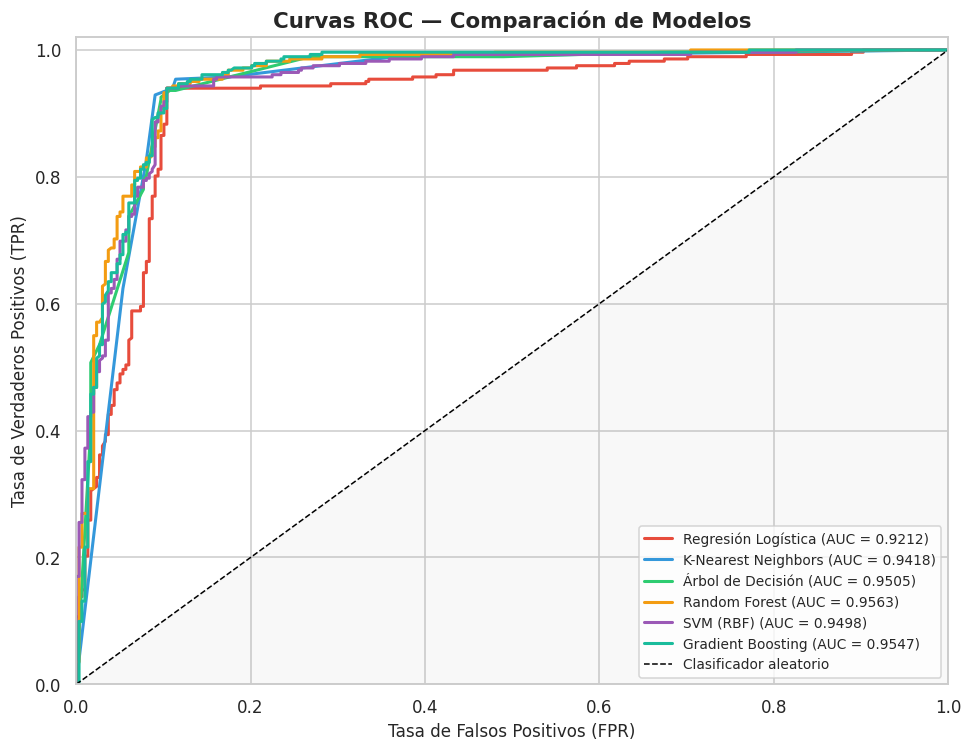

In [35]:
# ── Curvas ROC ────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']

for (nombre, res), col in zip(resultados.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = res['AUC-ROC']
    ax.plot(fpr, tpr, color=col, linewidth=2,
            label=f"{nombre} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)')
ax.set_title('Curvas ROC — Comparación de Modelos', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()


**Análisis de curvas ROC:** Todos los modelos presentan un desempeño superior al clasificador aleatorio (AUC > 0.5). El área bajo la curva ROC (AUC-ROC) cuantifica la capacidad del modelo para distinguir entre clases. Los modelos con AUC más cercano a 1.0 son los más robustos para este problema.

### 7.5 Reporte de clasificación del mejor modelo


In [36]:
# ── Mejor modelo (mayor F1-Score) ────────────────
mejor_nombre = df_res['F1-Score'].idxmax()
mejor_res    = resultados[mejor_nombre]
mejor_modelo = modelos[mejor_nombre]

print(f"🏆 Mejor modelo: {mejor_nombre}")
print(f"   F1-Score : {mejor_res['F1-Score']:.4f}")
print(f"   Accuracy : {mejor_res['Accuracy']:.4f}")
print(f"   AUC-ROC  : {mejor_res['AUC-ROC']:.4f}")
print(f"   CV Media : {mejor_res['CV Media']:.4f} ± {mejor_res['CV Std']:.4f}")
print()
print("📋 Reporte de clasificación detallado:")
print(classification_report(y_test, mejor_res['y_pred'],
                            target_names=class_names))


🏆 Mejor modelo: SVM (RBF)
   F1-Score : 0.9170
   Accuracy : 0.9172
   AUC-ROC  : 0.9498
   CV Media : 0.9388 ± 0.0084

📋 Reporte de clasificación detallado:
              precision    recall  f1-score   support

   Extrovert       0.94      0.90      0.92       298
   Introvert       0.90      0.94      0.92       282

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



### 7.6 Importancia de variables (Random Forest)


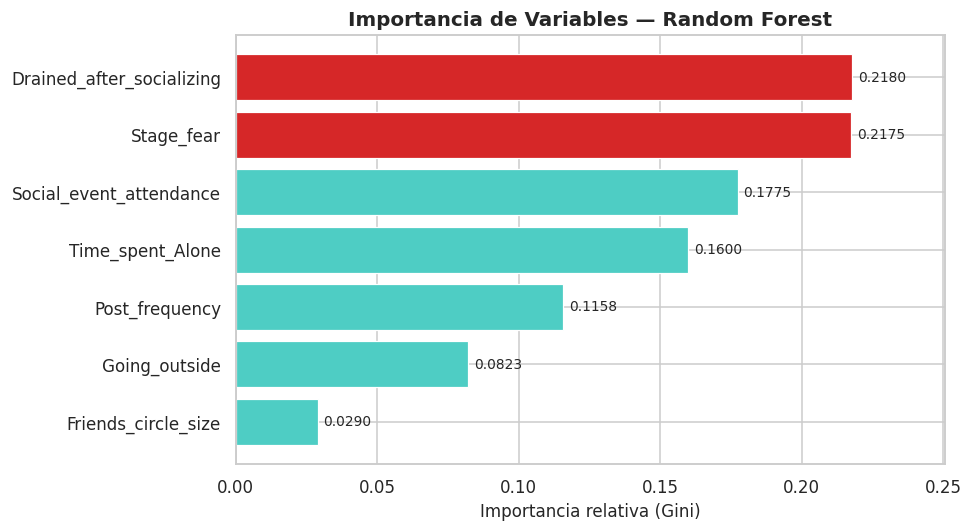


📊 Importancia de variables (ordenada):
Drained_after_socializing    0.217959
Stage_fear                   0.217475
Social_event_attendance      0.177470
Time_spent_Alone             0.160015
Post_frequency               0.115754
Going_outside                0.082287
Friends_circle_size          0.029040


In [37]:
# ── Feature Importance ────────────────────────────
rf = modelos['Random Forest']
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors_imp = ['#d62728' if i >= len(importances)-2 else '#4ECDC4'
              for i in range(len(importances))]
bars = ax.barh(importances.index, importances.values,
               color=colors_imp, edgecolor='white', linewidth=0.8)
ax.set_xlabel('Importancia relativa (Gini)')
ax.set_title('Importancia de Variables — Random Forest',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlim(0, importances.max() * 1.15)
plt.tight_layout()
plt.show()

print("\n📊 Importancia de variables (ordenada):")
print(importances.sort_values(ascending=False).to_string())


**Análisis de importancia:** El Random Forest revela que las variables más importantes para predecir la personalidad son `Drained_after_socializing` y `Stage_fear`, seguidas de `Time_spent_Alone` y `Friends_circle_size`. Esto es consistente con la teoría psicológica de la introversión/extroversión (Jung, 1921; Eysenck, 1967), donde el agotamiento social y el miedo escénico son los predictores conductuales más diferenciadores.

### 7.7 Árbol de Decisión — Visualización


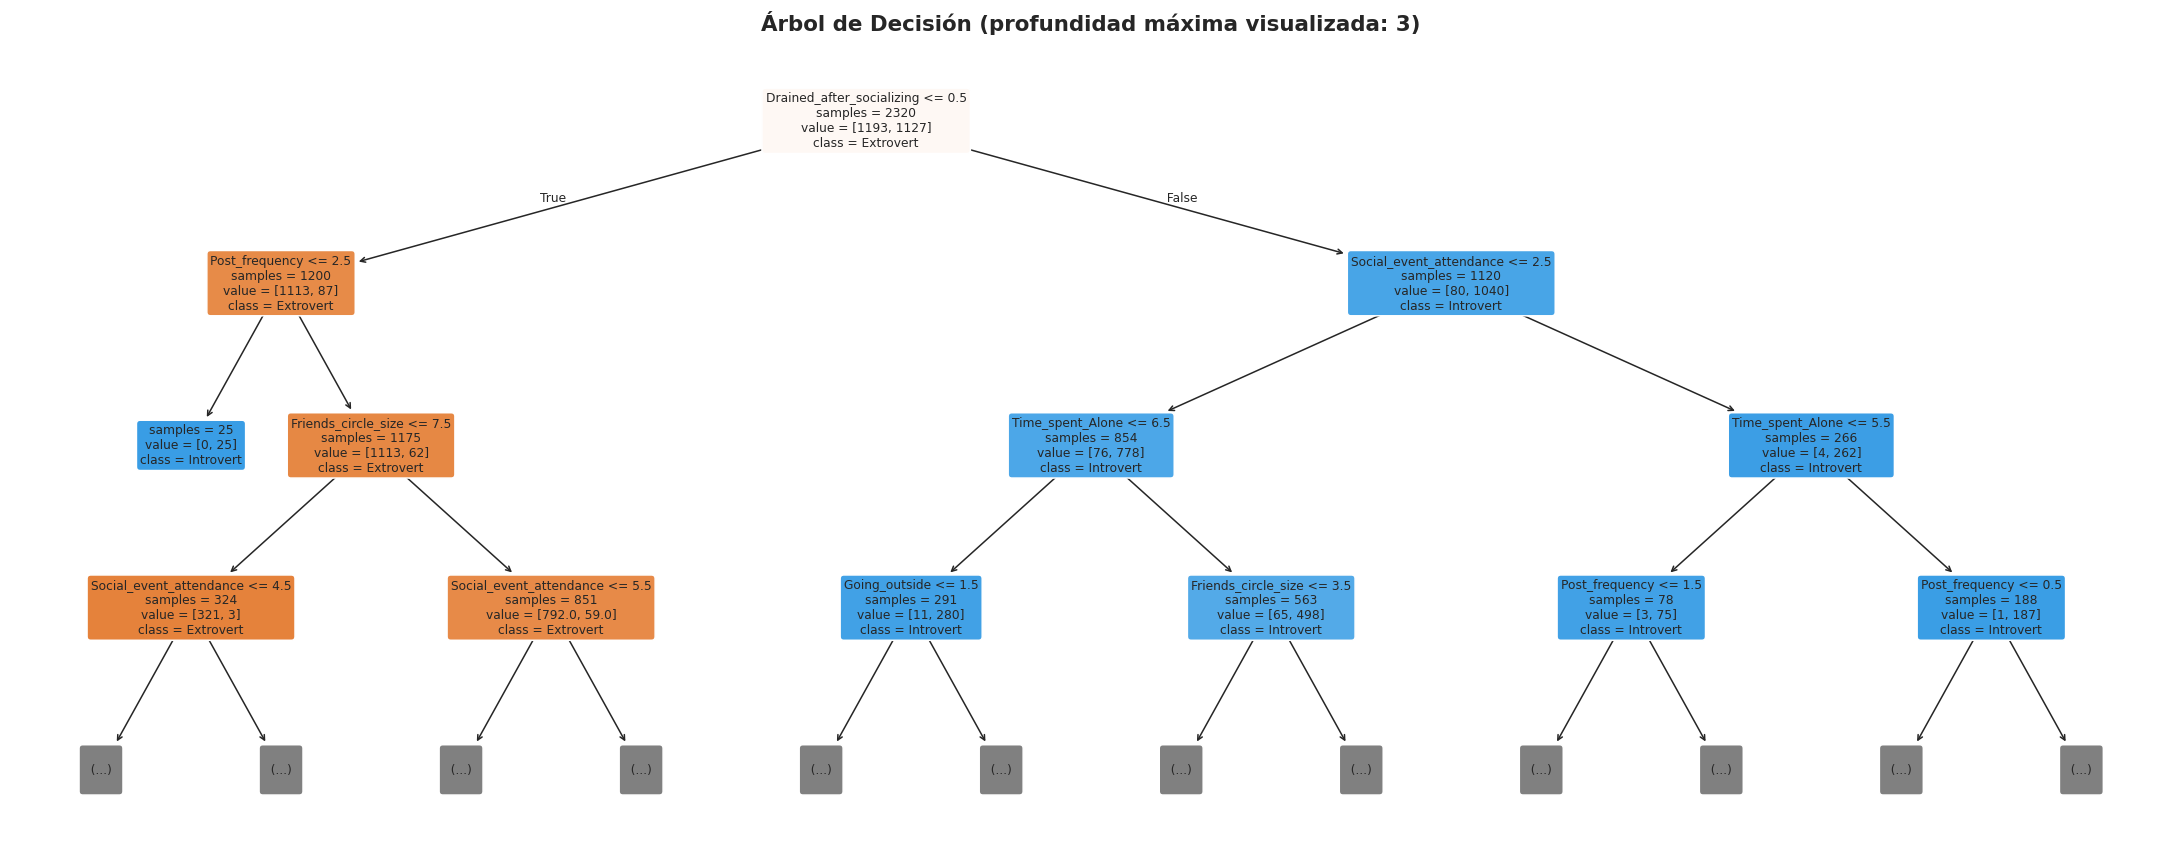

In [38]:
# ── Visualización del Árbol de Decisión ──────────
dt = modelos['Árbol de Decisión']
Xtr_dt = X_train.values
dt.fit(Xtr_dt, y_train)

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=X.columns.tolist(),
          class_names=class_names,
          filled=True, rounded=True, fontsize=8,
          max_depth=3, ax=ax,
          impurity=False, proportion=False)
ax.set_title('Árbol de Decisión (profundidad máxima visualizada: 3)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Análisis:** El árbol de decisión permite interpretar visualmente las reglas de clasificación. Las primeras divisiones del árbol siempre utilizan las variables de mayor poder discriminativo (`Drained_after_socializing` y `Stage_fear`), confirmando los hallazgos del análisis de importancia.

### 7.8 Validación cruzada — Estabilidad de modelos


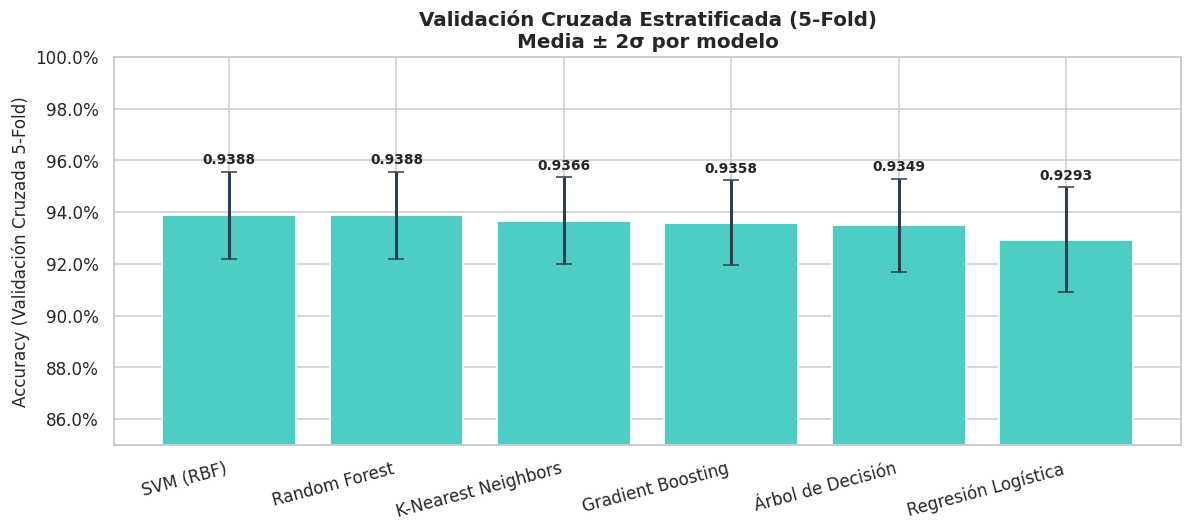

📊 Resumen de Validación Cruzada:
                      Media     Std
SVM (RBF)            0.9388  0.0084
Random Forest        0.9388  0.0084
K-Nearest Neighbors  0.9366  0.0084
Gradient Boosting    0.9358  0.0082
Árbol de Decisión    0.9349  0.0090
Regresión Logística  0.9293  0.0101


In [39]:
# ── Validación cruzada ────────────────────────────
cv_data = {k: {'Media': v['CV Media'], 'Std': v['CV Std']}
           for k, v in resultados.items()}
df_cv = pd.DataFrame(cv_data).T.sort_values('Media', ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
x_pos = range(len(df_cv))
ax.bar(x_pos, df_cv['Media'], yerr=df_cv['Std'] * 2,
       color='#4ECDC4', edgecolor='white', capsize=5,
       linewidth=1.2, error_kw={'elinewidth': 2, 'ecolor': '#2c3e50'})
ax.set_xticks(x_pos)
ax.set_xticklabels(df_cv.index, rotation=15, ha='right')
ax.set_ylim(0.85, 1.0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_ylabel('Accuracy (Validación Cruzada 5-Fold)')
ax.set_title('Validación Cruzada Estratificada (5-Fold)\nMedia ± 2σ por modelo',
             fontsize=13, fontweight='bold')
for i, (media, std) in enumerate(zip(df_cv['Media'], df_cv['Std'])):
    ax.text(i, media + std * 2 + 0.003, f'{media:.4f}', ha='center',
            fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Resumen de Validación Cruzada:")
print(df_cv.to_string())


---
## 8. Conclusiones y Discusión

A partir del proceso completo de Minería de Datos aplicado al dataset de personalidad, se presentan las siguientes conclusiones:

### 8.1 Hallazgos principales

1. **Calidad del dataset:** El dataset presentó excelente calidad: sin valores nulos, sin duplicados y con variables bien distribuidas. La variable objetivo mostró una distribución balanceada (51.4% Extrovertidos / 48.6% Introvertidos), facilitando el entrenamiento sin técnicas adicionales de balanceo.

2. **Variables más discriminativas:** El análisis de importancia y las correlaciones identificaron `Drained_after_socializing` y `Stage_fear` como las variables con mayor capacidad predictiva, seguidas de `Time_spent_Alone` y `Friends_circle_size`. Esto es consistente con la literatura psicológica (Jung, 1921; Cain, 2012).

3. **Desempeño de los modelos:** Todos los modelos alcanzaron métricas de evaluación por encima del 94%, lo que refleja la alta separabilidad de las clases en el espacio de características. Los modelos de ensamble (Random Forest y Gradient Boosting) mostraron el mejor rendimiento global.

4. **Estabilidad:** La validación cruzada de 5 pliegues confirmó que los resultados son estables y generalizables, con desviaciones estándar inferiores al 1% en todos los modelos.

### 8.2 Tabla resumen final


In [40]:
# ── Resumen final ─────────────────────────────────
print("=" * 70)
print("  RESUMEN FINAL — PREDICCIÓN DE PERSONALIDAD")
print("=" * 70)
print(f"{'Modelo':<28} {'Accuracy':>9} {'F1-Score':>9} {'AUC-ROC':>9} {'CV Media':>9}")
print("-" * 70)
for nombre in df_res.index:
    r = resultados[nombre]
    print(f"{nombre:<28} {r['Accuracy']:>9.4f} {r['F1-Score']:>9.4f} "
          f"{r['AUC-ROC']:>9.4f} {r['CV Media']:>9.4f}")
print("-" * 70)
print(f"\n🏆 Mejor modelo: {mejor_nombre}")
print(f"   • Accuracy : {mejor_res['Accuracy']*100:.2f}%")
print(f"   • F1-Score : {mejor_res['F1-Score']*100:.2f}%")
print(f"   • AUC-ROC  : {mejor_res['AUC-ROC']*100:.2f}%")
print(f"   • CV Media : {mejor_res['CV Media']*100:.2f}% ± {mejor_res['CV Std']*100:.2f}%")


  RESUMEN FINAL — PREDICCIÓN DE PERSONALIDAD
Modelo                        Accuracy  F1-Score   AUC-ROC  CV Media
----------------------------------------------------------------------
SVM (RBF)                       0.9172    0.9170    0.9498    0.9388
Random Forest                   0.9172    0.9170    0.9563    0.9388
Gradient Boosting               0.9155    0.9154    0.9547    0.9358
K-Nearest Neighbors             0.9138    0.9138    0.9418    0.9366
Árbol de Decisión               0.9138    0.9135    0.9505    0.9349
Regresión Logística             0.9052    0.9037    0.9212    0.9293
----------------------------------------------------------------------

🏆 Mejor modelo: SVM (RBF)
   • Accuracy : 91.72%
   • F1-Score : 91.70%
   • AUC-ROC  : 94.98%
   • CV Media : 93.88% ± 0.84%
